In [1]:
import numpy as np
import pandas as pd
import glob, os, subprocess, vcf, shutil, sparse, yaml, sys, pickle, itertools
from Bio import Entrez, Seq, SeqIO, SeqUtils
import scipy.stats as st

# utils files are in a separate folder
os.chdir("../")
sys.path.append("utils")
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
output_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# full_data = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
cc_df_who = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

df_MIC_ML = pd.read_csv("./MIC_data/MIC_ML.csv")
df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_normalized.csv")

df_samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
# df_samples_geno['log_F2'] = np.log2(df_samples_geno['F2'])

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_variants_WHO_catalog.csv").dropna(subset='variant').reset_index(drop=True)
all_drugs_insilico_pred = pd.read_csv("supplement/insilico_pred_all.csv")
H37Rv_insilico_pred = all_drugs_insilico_pred.query("variant=='MT_H37Rv'").reset_index(drop=True)

# Look at the Distribution of ethionamide MICs stratified by number of LoFs in possible activators

In [2]:
def get_isolates_with_LoF(df, gene, include_frameshift=True):
    
    df_check_variants = isolate_variants.query("ROLLINGDB_ID in @df.ROLLINGDB_ID.values")
    
    if include_frameshift:
        LoF_lst = ['start_lost', 'stop_gained', 'frameshift_variant', 'ablation']
    else:
        LoF_lst = ['start_lost', 'stop_gained', 'ablation']        

    isolates_with_LoF = df_check_variants.query("GENE==@gene & EFFECT.str.contains('|'.join(@LoF_lst))").ROLLINGDB_ID.values
    
    df[f"{gene}_LoF"] = df['ROLLINGDB_ID'].isin(isolates_with_LoF).astype(int)
    
    return df

In [31]:
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv").query("Span_CC==0")
df_ETO['Binary'] = df_ETO['Binary'].astype(int)

ETO_isolates = df_ETO.ROLLINGDB_ID.values
print(len(ETO_isolates))

genes_of_interest = ['ethA', 'mshA', 'ndh', 'Rv3083', 'Rv0565c']#, 'ethR']

for gene in genes_of_interest:
    df_ETO = get_isolates_with_LoF(df_ETO, gene)

10120


In [32]:
gene_LoF_cols = [f"{col}_LoF" for col in genes_of_interest]
df_ETO['Num_LoF'] = df_ETO[gene_LoF_cols].sum(axis=1)

In [33]:
df_ETO.groupby('Num_LoF')['Binary'].mean()

Num_LoF
0    0.130162
1    0.348497
2    0.456731
3    0.888889
Name: Binary, dtype: float64

In [35]:
# df_ETO.query("ethR_LoF==1").ethA_LoF.value_counts()

In [36]:
# df_ETO.groupby(['ethR_LoF', 'ethA_LoF']).Binary.mean()

In [37]:
for i, num in enumerate(df_ETO['Num_LoF'].unique()):
    
    if i > 0:
        
        previous_num = df_ETO['Num_LoF'].unique()[i-1]
        
        _, pval = st.ttest_ind(np.log2(df_ETO.query("Num_LoF==@num")['ETO_midpoint']),
                               np.log2(df_ETO.query("Num_LoF==@previous_num")['ETO_midpoint']),
                               equal_var=False,
                               alternative='greater'
                              )
        
        print(f"{num} LoFs vs. {previous_num} LoFs: p = {pval}")

1 LoFs vs. 0 LoFs: p = 1.4305232235814535e-136
2 LoFs vs. 1 LoFs: p = 0.0030211495244289134
3 LoFs vs. 2 LoFs: p = 3.6159347970955e-07


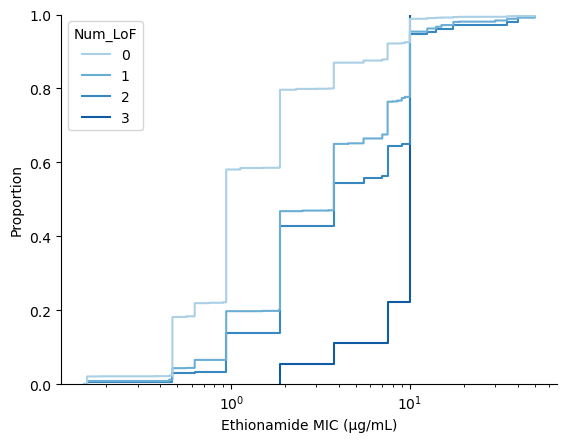

In [38]:
sns.ecdfplot(data=df_ETO,
             x='ETO_midpoint',
             hue='Num_LoF',
             log_scale=10,
             palette=sns.color_palette('Blues', n_colors=5).as_hex()[1:], # the first color is very faint, so skip it
            )

plt.xlabel('Ethionamide MIC (µg/mL)')

sns.despine()
plt.savefig("./results/Ethionamide/MIC_distribution_by_LoF_count.svg", bbox_inches='tight')

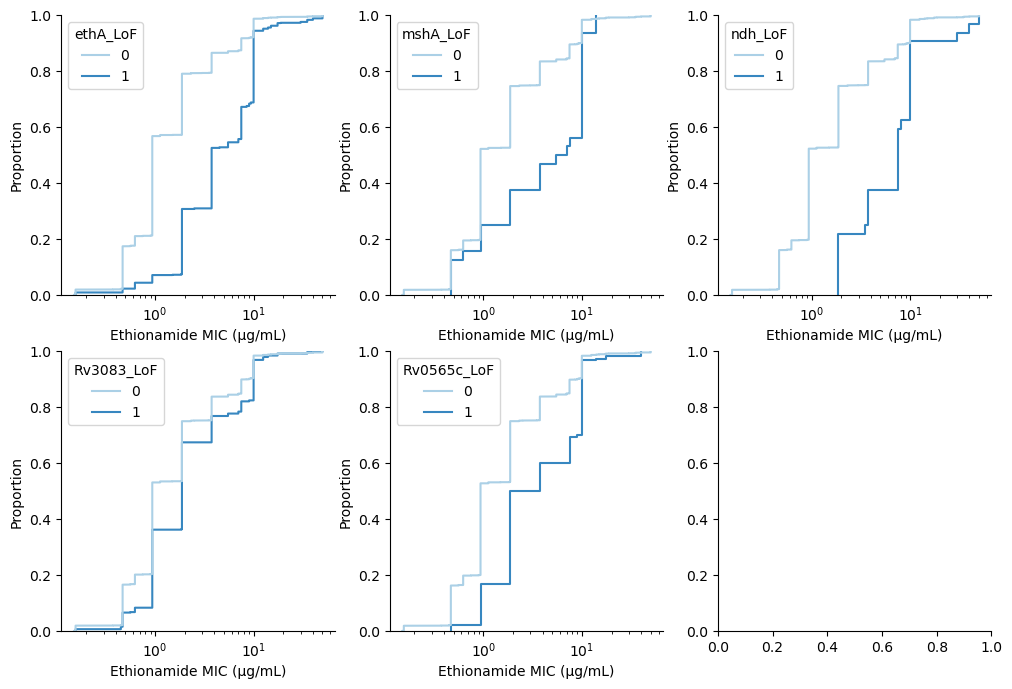

In [39]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for i, gene in enumerate(genes_of_interest):
        
    LoF_col = f"{gene}_LoF"

    sns.ecdfplot(data=df_ETO,
                 x='ETO_midpoint',
                 hue=LoF_col,
                 log_scale=10,
                 palette='Blues',
                 ax=axs[i]
                )

    pval = st.ttest_ind(np.log2(df_ETO.query(f"{LoF_col}==0")['ETO_midpoint']),
                        np.log2(df_ETO.query(f"{LoF_col}==1")['ETO_midpoint']),
                        alternative='less',
                        equal_var=False
                       )[1]
    
    num_isolates_with_LoF = len(df_ETO.query(f"{LoF_col}==1"))

    # axs[i].set_title(f"{genes_of_interest[i]}, p = {pval}\nN = {num_isolates_with_LoF}")
    axs[i].set_xlabel('Ethionamide MIC (µg/mL)')

sns.despine()
plt.savefig("./results/Ethionamide/MIC_distribution_by_single_gene_LoF.svg", bbox_inches='tight')

# MIC Distributions of Isolates without an ethA LoF, but an LoF in another gene

In [40]:
df_no_ethA_LoF = df_ETO.query("ethA_LoF==0")

# update to exclude ethA LoF
del df_no_ethA_LoF['Num_LoF']
df_no_ethA_LoF['Num_LoF'] = df_no_ethA_LoF[df_no_ethA_LoF.columns[df_no_ethA_LoF.columns.str.endswith('LoF')]].sum(axis=1)

len(df_no_ethA_LoF)

9171

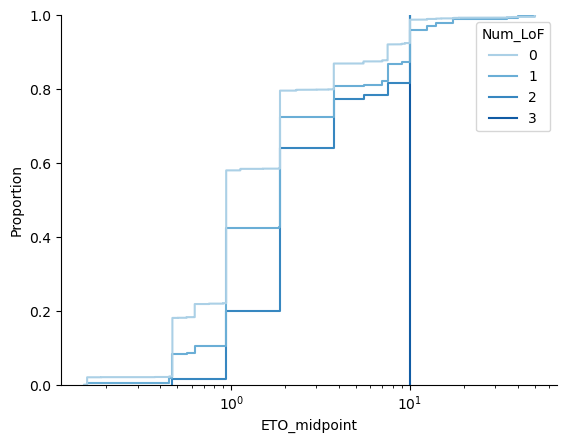

In [41]:
sns.ecdfplot(data=df_no_ethA_LoF,
             x='ETO_midpoint',
             hue='Num_LoF',
             log_scale=10,
             palette=sns.color_palette('Blues', n_colors=5).as_hex()[1:], # the first color is very faint, so skip it
            )

sns.despine()
plt.show()

In [11]:
df_no_ethA_LoF.query("Num_LoF==3")

,ROLLINGDB_ID,ETO_MEDIA,ETO_lower_bound,ETO_midpoint,ETO_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,...,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,ndh_LoF,Rv3083_LoF,Rv0565c_LoF,Num_LoF
3642,SAMEA7525944,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,4.8,4.2.1.1.1.1.1.1.i1,NaN,...,0,1,4-1,train_set,0,1,0,1,1,3


In [12]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA7525944' & GENE in @genes_of_interest").drop_duplicates('variant')

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
288449,SAMEA7525944,575871,A,AC,PASS,4800.0,NaN,0.99,143.0,34.0,60.0,NaN,NaN,frameshift_variant,mshA,NaN,NaN,mshA_LoF,Ethionamide,3) Uncertain significance
288451,SAMEA7525944,575871,A,AC,PASS,4800.0,False,0.99,143.0,34.0,60.0,141.0,0.0,frameshift_variant,mshA,c.525dupC,p.Thr176fs,mshA_p.Thr176fs,Ethionamide,3) Uncertain significance
288453,SAMEA7525944,656265,CGT,C,PASS,0.0,False,1.00,98.0,0.0,60.0,0.0,98.0,frameshift_variant,Rv0565c,c.1204_1205delAC,p.Thr402fs,Rv0565c_p.Thr402fs,Ethionamide,3) Uncertain significance
288454,SAMEA7525944,656265,CGT,C,PASS,0.0,NaN,1.00,98.0,0.0,60.0,NaN,NaN,frameshift_variant,Rv0565c,NaN,NaN,Rv0565c_LoF,Ethionamide,3) Uncertain significance
288465,SAMEA7525944,2101877,C,T,PASS,3670.0,False,1.00,110.0,33.0,60.0,0.0,0.0,missense_variant,ndh,c.1166G>A,p.Gly389Asp,ndh_p.Gly389Asp,Delamanid,3) Uncertain significance
288475,SAMEA7525944,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,frameshift_variant,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance


# How many of the isolates without ethA LoF with at least one other LoF are resistant?

In [13]:
df_ETO.groupby('Num_LoF').Binary.mean()

Num_LoF
0    0.130162
1    0.348497
2    0.456731
3    0.888889
Name: Binary, dtype: float64

In [14]:
df_no_ethA_LoF.groupby('Num_LoF').Binary.mean()

Num_LoF
0    0.130162
1    0.192053
2    0.225000
3    1.000000
Name: Binary, dtype: float64

# Correlations between LoF variants in the 5 genes

In [23]:
df_ETO[gene_LoF_cols].corr(method='spearman')

,ethA_LoF,mshA_LoF,ndh_LoF,Rv3083_LoF,Rv0565c_LoF,ethR_LoF
ethA_LoF,1.000000,-0.012080,0.024145,0.035425,0.049035,0.312973
mshA_LoF,-0.012080,1.000000,-0.003172,0.024235,0.005737,-0.005850
ndh_LoF,0.024145,-0.003172,1.000000,-0.013811,-0.007579,-0.005850
Rv3083_LoF,0.035425,0.024235,-0.013811,1.000000,0.400103,-0.004680
Rv0565c_LoF,0.049035,0.005737,-0.007579,0.400103,1.000000,0.036954
ethR_LoF,0.312973,-0.005850,-0.005850,-0.004680,0.036954,1.000000


<Axes: >

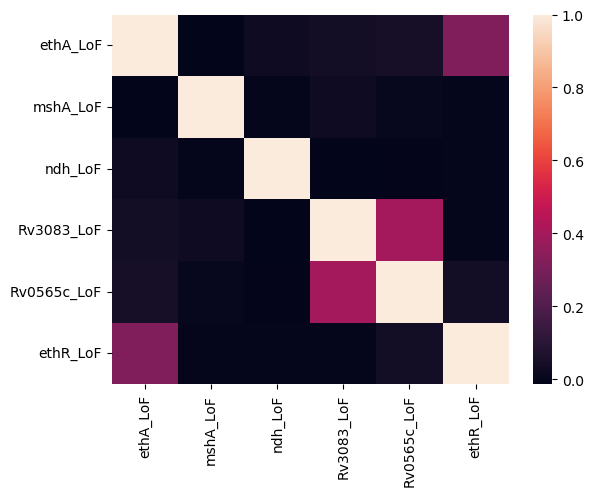

In [24]:
sns.heatmap(df_ETO[gene_LoF_cols].corr(method='spearman'))

In [26]:
# fNames = [f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/{sample}.vcf" for sample in df_ETO.ROLLINGDB_ID.values]

# for fName in fNames:
#     assert os.path.isfile(fName)
    
# pd.Series(fNames).to_csv("/home/sak0914/MtbQuantCNN/results/Ethionamide/VCF_isolates_no_span_CC.txt", sep='\t', header=None, index=False)

In [30]:
df_ETO.query("Num_LoF > 0").Lineage.value_counts()

Lineage
4    911
2    544
3     52
1     16
Name: count, dtype: int64